# Analiza ogłoszeń mieszkań w Krakowie - Kacper Osmola 2026

In [1]:
!pip install geopandas


In [2]:
!pip install beautifulsoup4

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn3

import geopandas
import zipfile, re, os
import requests
from bs4 import BeautifulSoup

# Wczytanie danych

In [5]:
url = 'https://www.otodom.pl/pl/wyniki/sprzedaz/mieszkanie/malopolskie/krakow/krakow/krakow?page='
headers = {'User-Agent' : 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.36'}
pages = []
for i in range(1, 342):
  page = requests.get(url + str(i), headers=headers)
  pages.append(page)
  if i % 20 == 0:
    print(i)

20
40
60
80
100
120
140
160
180
200
220
240
260
280
300
320
340


In [15]:
offerts_links = []
for i, page in enumerate(pages):
  if i % 20 == 0:
    print(i)
  soup = BeautifulSoup(page.content, 'html.parser')
  main_block = soup.select_one('div', _class = 'search.listing.organic')
  offerts = main_block.find_all('li')
  for li in offerts:
    try:
      link = li.find('a')['href']
      if '/pl/oferta' in link:
        offerts_links.append(link)
    except:
      pass

0
20
40
60
80
100
120
140
160
180
200
220
240
260
280
300
320
340


In [34]:
offerts_pages = []
for i, link in enumerate(offerts_links):
  if i % 100 == 0:
    print(i)
  new_page = requests.get(f'https://www.otodom.pl/{link}', headers=headers).content
  offerts_pages.append(new_page)

0
100
200
300
400


KeyboardInterrupt: 

In [ ]:
pre_df = {}
for i, page in enumerate(offerts_pages):
  if i % 100 == 0:
    print(i)
  try:
    soup = BeautifulSoup(page, 'html.parser')
    rows = soup.find_all('div', class_ = 'css-1xw0jqp efdvw050')
    for row in rows:
      double = row.find_all('div')
      attr = double[0].text
      value = double[1].text
      if attr in pre_df:
        pre_df[attr].append(value)
      else:
        pre_df[attr] = [value]
  except:
    pass


Jako że sam web scraping zajmuje dużo czasu, a progres resetuje się na google collabie, zapisuję w formie jsona słownik aby kontynuować czyszczenie danych później

In [ ]:
import json
with open('offerts.json', 'w') as f:
  json.dump(pre_df, f)

In [ ]:
test_df = pd.DataFrame(pre_df)
test_df.head(3)

STOP

In [ ]:
df_krk['District'] = df_krk['Location'].apply(lambda x : x.split(',')[-3].strip().upper())
df_krk['District']

/tmp/ipykernel_271/970824843.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_krk['District'] = df_krk['Location'].apply(lambda x : x.split(',')[-3].strip().upper())


,District
33,CZYŻYNY
50,PRĄDNIK BIAŁY
75,KROWODRZA
76,PRĄDNIK BIAŁY
84,NOWA HUTA
...,...
2782,PODGÓRZE
2783,GRZEGÓRZKI
2790,PODGÓRZE
2791,WZGÓRZA KRZESŁAWICKIE


- rozkład cen według dzielnicy
- średnia cena na metr na dzielnice
- ogrzewanie a cena
- wysokość budynku według dzielnicy

# Analiza

## Rozkład cen i powierzchni

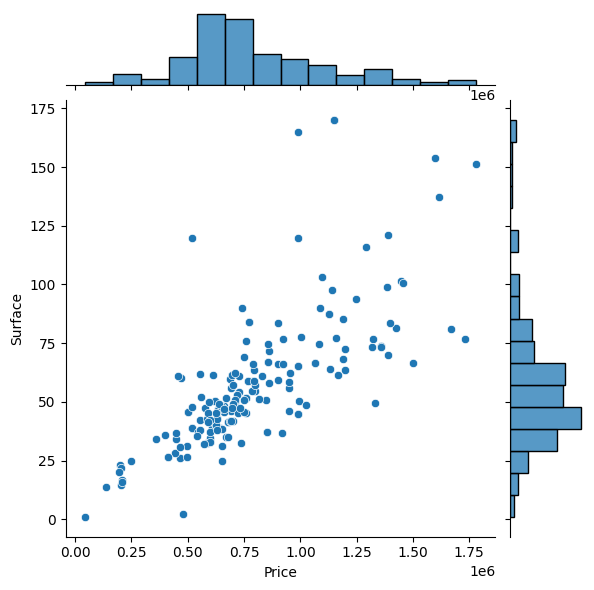

In [ ]:
sns.jointplot(data= df_krk[(df_krk.Price <= 2000000) & (df_krk.Surface <= 200)], x='Price', y='Surface')

## Ilość ofert w dzielnicach

<Axes: >

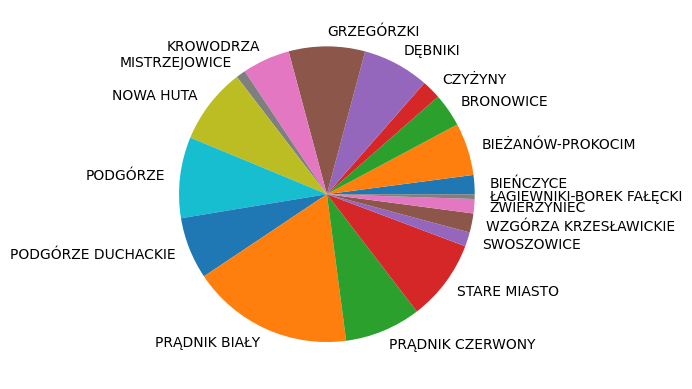

In [ ]:
df_krk.groupby('District')['Title'].count().plot(kind='pie', ylabel='')

## Ilość ofert z balkonem, ogródkiem lub tarasem

In [ ]:
df_krk.loc[df_krk.Balcony_Garden_Terrace == 'taras, ogródek', 'Balcony_Garden_Terrace'] = 'ogródek, taras'
bgt = df_krk.groupby('Balcony_Garden_Terrace')['Title'].count()

In [ ]:
positions = {'balkon': 0, 'ogródek': 1, 'balkon, ogródek': 2, 'taras': 3, 'balkon, taras':4, 'ogródek, taras': 5, 'balkon, ogródek, taras': 6}

In [ ]:
bgt = bgt.sort_index(key=lambda x: [positions[i] for i in x])

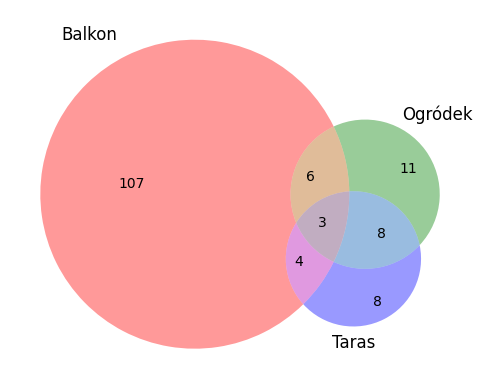

In [ ]:
venn3(subsets = bgt.values, set_labels = ('Balkon', 'Ogródek', 'Taras'))

## Rozkład ceny metra kwadratowego

/tmp/ipykernel_271/2648573698.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_krk['Price_m2'] = df_krk['Price'] / df_krk['Surface']


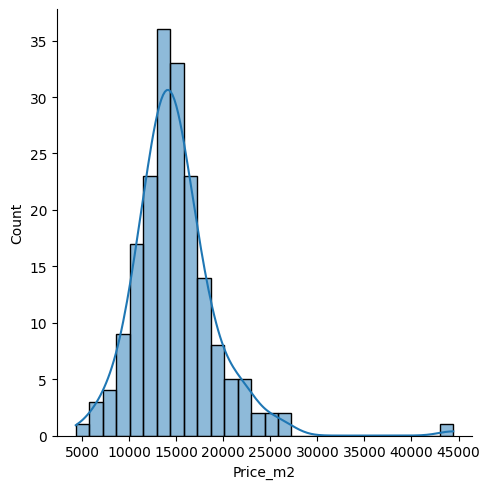

In [ ]:
df_krk['Price_m2'] = df_krk['Price'] / df_krk['Surface']
normal_price = df_krk[df_krk.Price_m2 <= 50000]
sns.displot(data = normal_price['Price_m2'], kde=True)

## Średnia cena metra kwadratowego według piętra

In [ ]:
sorter = {'suterena': 0, 'parter': 1, '1': 2, '2': 3, '3': 4, '4' : 5, '5':6, '6':7, '7': 8, '8': 9, '9': 10, '10': 11, '> 10': 12}

/tmp/ipykernel_271/211318794.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_krk['Floor_abs'] = df_krk['Floor'].apply(lambda x : str(x).split('/')[0].strip())


<Axes: title={'center': 'Avg price per m2 for each floor'}, xlabel='Floor_abs', ylabel='price per m2'>

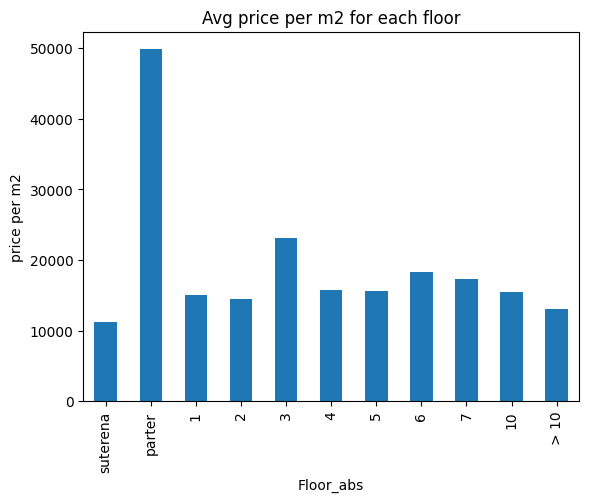

In [ ]:
df_krk['Floor_abs'] = df_krk['Floor'].apply(lambda x : str(x).split('/')[0].strip())
to_plot = df_krk[df_krk.Floor_abs != 'nan']
to_plot = to_plot.groupby('Floor_abs')['Price_m2'].mean()
to_plot = to_plot[to_plot != 'nan']

to_plot.sort_index(key=lambda x: [sorter[i] for i in x]).plot(kind='bar', title='Avg price per m2 for each floor', ylabel='price per m2')

## Rozkład cen metra kwadratowego według stanu wykończenia

<Axes: xlabel='Finishing_Condition', ylabel='Price_m2'>

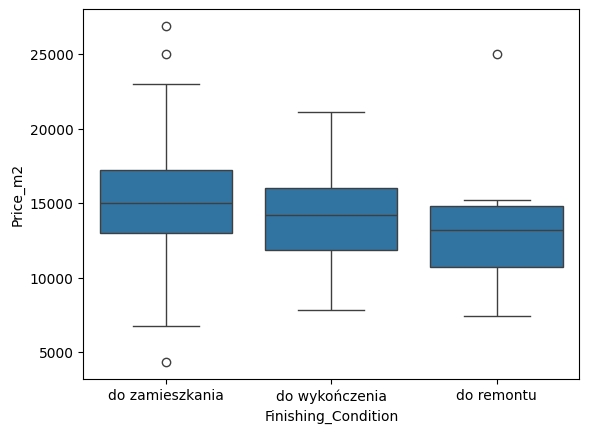

In [ ]:
to_plot = df_krk[df_krk.Price_m2 < 50000]
sns.boxplot(x = to_plot.Finishing_Condition, y=to_plot.Price_m2)

In [ ]:
url = 'https://gis-support.pl/wp-content/uploads/dzielnice_Krakowa.zip'
r = requests.get(url, allow_redirects=True)
f = open('dzielnice_Krakowa.zip', 'wb')
f.write(r.content)
f.close()

In [ ]:
districts = geopandas.read_file('zip://dzielnice_Krakowa.zip/dzielnice_Krakowa.dbf', encoding='utf-8')
districts['nazwa'] = districts['nazwa'].str.upper()
districts.head(3)

,objectid,mslink,mapid,id_dzielni,nr_dzielni,powierzchn,nazwa,nazwa_peln,opis,data_aktua,st_area(sh,st_length(,geometry
0,1.0,1.0,3013.0,1.0,I,5567646.0,STARE MIASTO,Dzielnica I Stare Miasto,UCHWALA NR XCIX/1495/14 RADY MIASTA KRAKOWA,2014-04-01,5.567646e+06,11730.268840,"POLYGON ((566097.26 244329.716, 566097.477 244..."
1,2.0,2.0,3013.0,2.0,II,5845232.0,GRZEGÓRZKI,Dzielnica II Grzegórzki,UCHWAŁA NR XCIX/1496/14 RADY MIASTA KRAKOWA,2014-04-01,5.845232e+06,11863.161038,"POLYGON ((567784.5 244043.139, 567786.287 2440..."
2,3.0,3.0,3013.0,3.0,III,6437857.0,PRĄDNIK CZERWONY,Dzielnica III Prądnik Czerwony,UCHWAŁA NR XCIX/1497/14 RADY MIASTA KRAKOWA,2014-04-01,6.437857e+06,13926.658887,"POLYGON ((567758.514 246401.517, 567774.358 24..."


## Średnia cena metra kwadratowego według dzielnicy

In [ ]:
to_merge = df_krk[df_krk['Price_m2'] <= 100000]
to_merge = to_merge.groupby('District')['Price_m2'].mean()
to_merge = pd.merge(districts, to_merge, left_on='nazwa', right_on='District')

In [ ]:
def graph_map(df, variable):
  fig, ax = plt.subplots(figsize=(10, 10))
  df.plot(column=variable, cmap='summer_r', linewidth=1.5, ax=ax)
  vmin, vmax = df[variable].min(), df[variable].max()
  sm = plt.cm.ScalarMappable(cmap='summer_r', norm=plt.Normalize(vmin=vmin, vmax=vmax))
  sm._A = []
  fig.colorbar(sm, shrink=0.5, ax=ax)
  plt.title('Average price per m2 in districts')
  ax.axis('off')

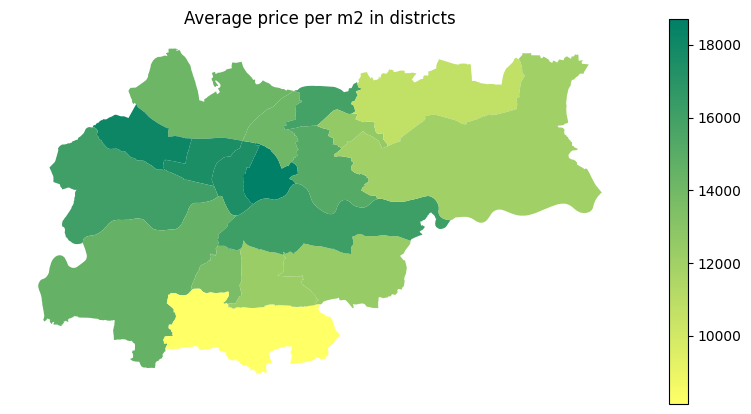

In [ ]:
graph_map(to_merge, 'Price_m2')